In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
from time import time
import logging
from utils.clause_visualization import visualize_aggregated_heatmap, visualize_per_channel_heatmaps, visualize_per_channel_level_heatmaps, visualize_average_heatmap

2026-03-07 19:49:47,269 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-03-07 19:49:47,275 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-03-07 19:49:47,287 - matplotlib - DEBUG - interactive is False
2026-03-07 19:49:47,288 - matplotlib - DEBUG - platform is linux
2026-03-07 19:49:47,559 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-03-07 19:49:47,561 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
num_clauses = 2000
T = 1500
s = 10.0
max_included_literals = 32
device = "CPU"
epochs = 10
patch_size = 10
weighted_clauses=True 
resolution=3

In [3]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

In [4]:
import numpy as np

def make_shapes_dataset(n_samples=6000, img_size=32, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n_samples, img_size, img_size, 3), dtype=np.uint8)
    Y = np.zeros(n_samples, dtype=np.uint32)

    for i in range(n_samples):
        cls = i % 3
        Y[i] = cls
        cx = img_size // 2 + rng.integers(-4, 4)
        cy = img_size // 2 + rng.integers(-4, 4)
        r  = rng.integers(6, 11)
        X[i] = 0

        if cls == 0:
            # YELLOW circle — R+G channels both active (mixed color)
            color = np.array([255, 200, 50], dtype=np.uint8)
            for y in range(img_size):
                for x in range(img_size):
                    if (x - cx)**2 + (y - cy)**2 <= r**2:
                        X[i, y, x] = color

        elif cls == 1:
            # CYAN rectangle — G+B channels both active
            color = np.array([50, 200, 255], dtype=np.uint8)
            x1, y1 = cx - r, cy - r
            x2, y2 = cx + r, cy + r
            X[i, max(0,y1):min(img_size,y2),
                 max(0,x1):min(img_size,x2)] = color

        else:
            # MAGENTA triangle — R+B channels both active
            color = np.array([255, 50, 200], dtype=np.uint8)
            for y in range(img_size):
                for x in range(img_size):
                    if (y >= cy - r and
                        y <= cy + r and
                        x >= cx - (y - (cy - r)) and
                        x <= cx + (y - (cy - r))):
                        X[i, y, x] = color

    return X, Y

# generate
X_all, Y_all = make_shapes_dataset(n_samples=6000, img_size=32)

# split
split_train = int(0.70 * len(X_all))
split_val   = int(0.85 * len(X_all))
X_train_org = X_all[:split_train]
Y_train     = Y_all[:split_train]
X_val_org   = X_all[split_train:split_val]
Y_val       = Y_all[split_train:split_val]
X_test_org  = X_all[split_val:]
Y_test      = Y_all[split_val:]

labels = {0: "Circle", 1: "Rectangle", 2: "Triangle"}
print("Raw shapes:", X_train_org.shape, X_val_org.shape, X_test_org.shape)

Raw shapes: (4200, 32, 32, 3) (900, 32, 32, 3) (900, 32, 32, 3)


In [5]:
import numpy as np

def encode_thermometer(X_org, resolution):
    """Encode (N, H, W, C) -> (N, H, W, C*resolution) using thermometer encoding."""
    N, H, W, C = X_org.shape
    X_enc = np.empty((N, H, W, C, resolution), dtype=np.uint8)
    for lvl in range(resolution):
        X_enc[:, :, :, :, lvl] = X_org >= (lvl + 1) * 255 / (resolution + 1)
    return X_enc.reshape(N, H, W, C * resolution)

# ---- Encode ----
X_train = encode_thermometer(X_train_org, resolution)
X_val   = encode_thermometer(X_val_org,   resolution)
X_test  = encode_thermometer(X_test_org,  resolution)

# ---- Label flattening ----
Y_train = Y_train.flatten()
Y_val   = Y_val.flatten()
Y_test  = Y_test.flatten()

# ---- Cast to uint32 for TMU ----
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_train = Y_train.astype(np.uint32)
Y_val   = Y_val.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)

N_CHANNELS = X_train_org.shape[3]
print("Encoded shapes:", X_train.shape, X_val.shape, X_test.shape)
print(f"  expect: (N, 32, 32, {N_CHANNELS * resolution})")
print("Labels:", Y_train.shape, Y_val.shape, Y_test.shape)

Encoded shapes: (4200, 32, 32, 9) (900, 32, 32, 9) (900, 32, 32, 9)
  expect: (N, 32, 32, 9)
Labels: (4200,) (900,) (900,)


In [6]:
tm = TMClassifier(
        number_of_clauses=num_clauses,
        T=T,
        s=s,
        max_included_literals=max_included_literals,
        platform="CPU",
        weighted_clauses=weighted_clauses,
        patch_dim=(patch_size, patch_size),
    )

In [7]:
for epoch in range(3):
        start = time()

        tm.fit(X_train, Y_train, epochs=1, incremental=True)

        stop = time()

        Y_pred, class_sums = tm.predict(X_test, return_class_sums=True)

        acc = 100.0 * (Y_pred == Y_test).mean()
        print(f"#{epoch+1} Accuracy: {acc:.2f}% ({stop-start:.2f}s)")

#1 Accuracy: 100.00% (65.42s)
#2 Accuracy: 100.00% (60.15s)
#3 Accuracy: 100.00% (60.52s)


In [8]:
import pickle 

with open("multichannel_synthetic_resolution.pkl", "wb") as f:
    pickle.dump(tm, f)

In [9]:
with open("multichannel_synthetic_resolution.pkl", "rb") as f:
    tm = pickle.load(f)

Showing sample index: 44


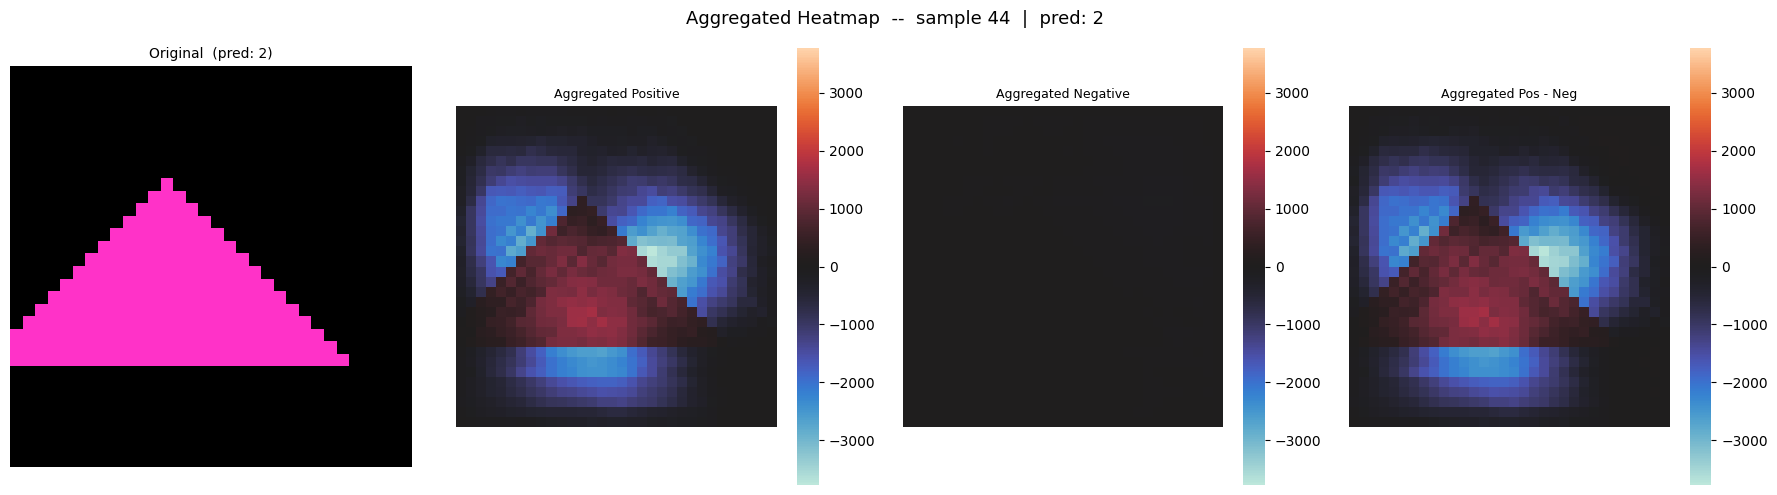

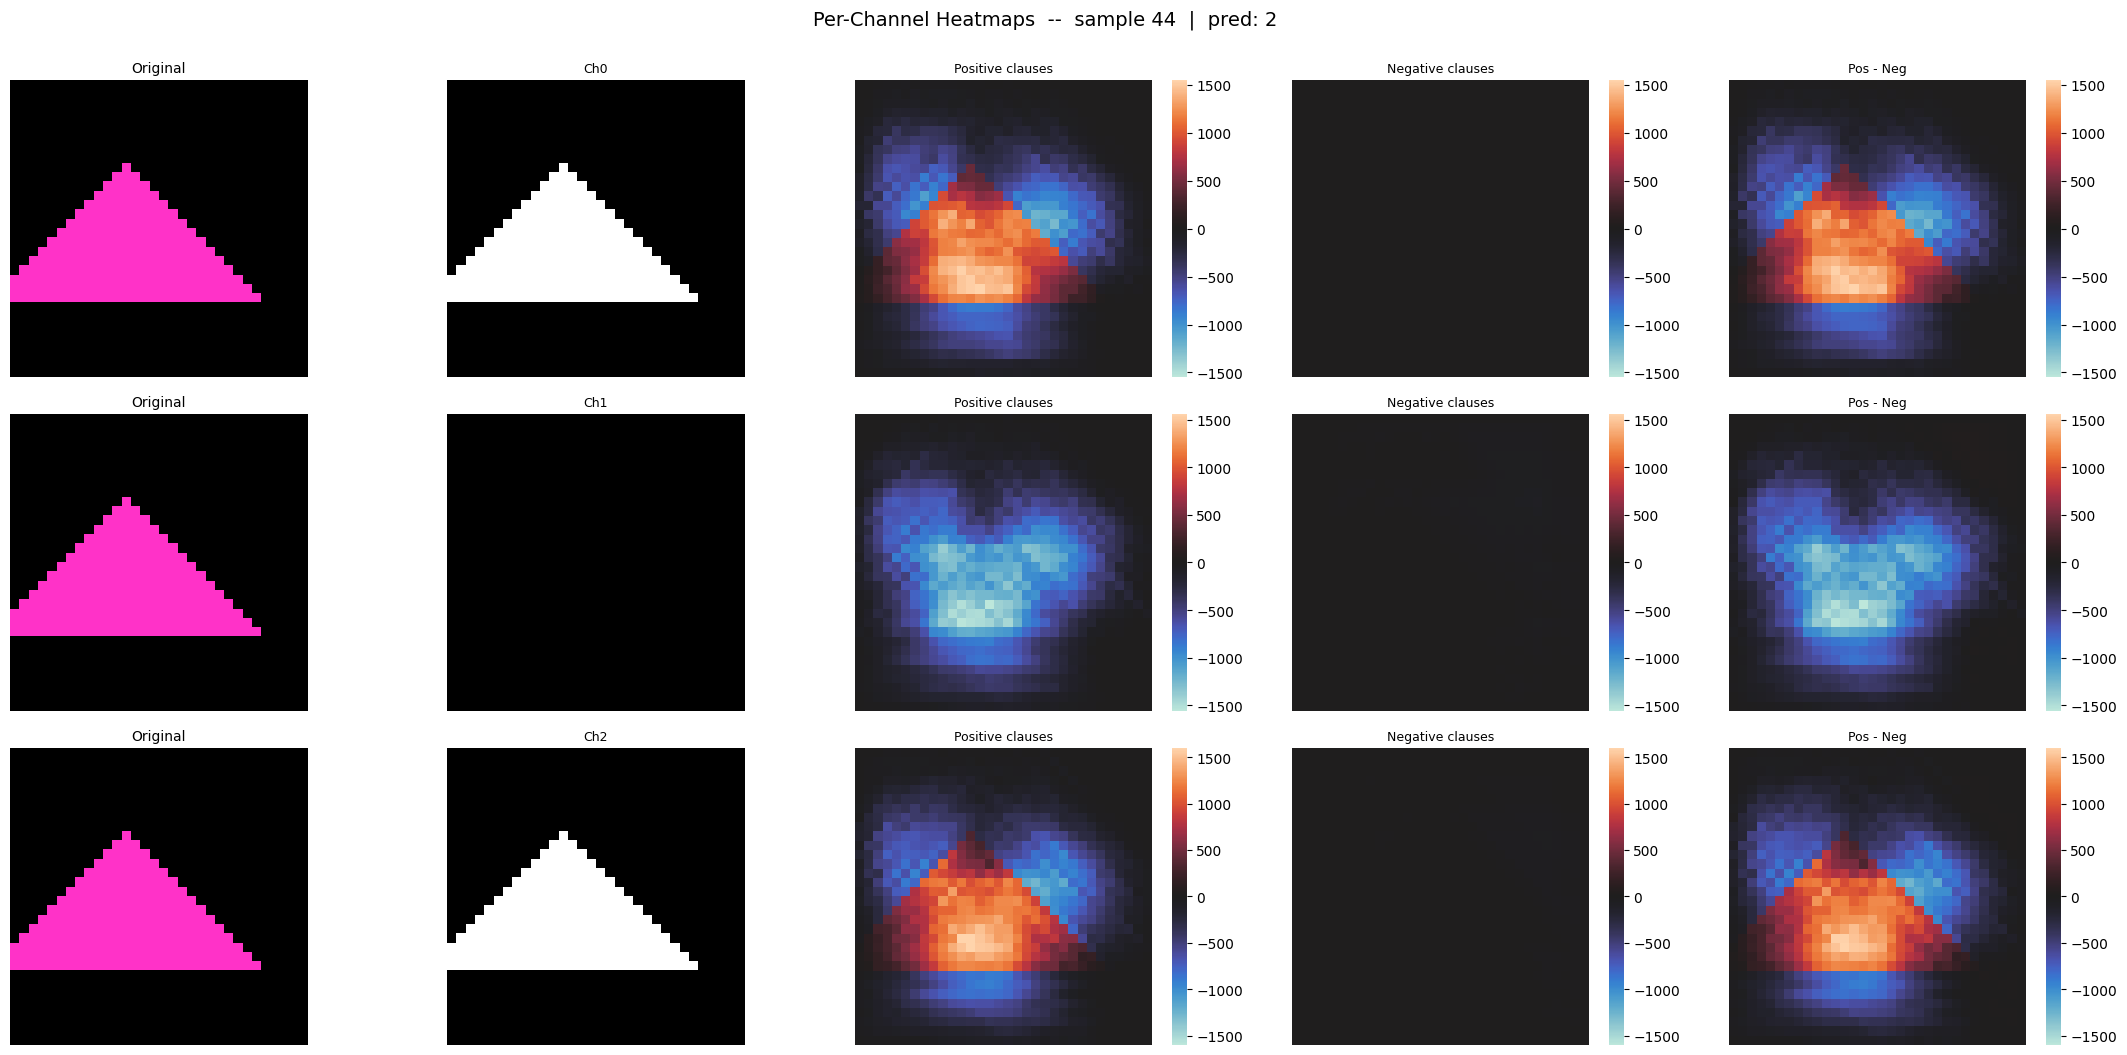

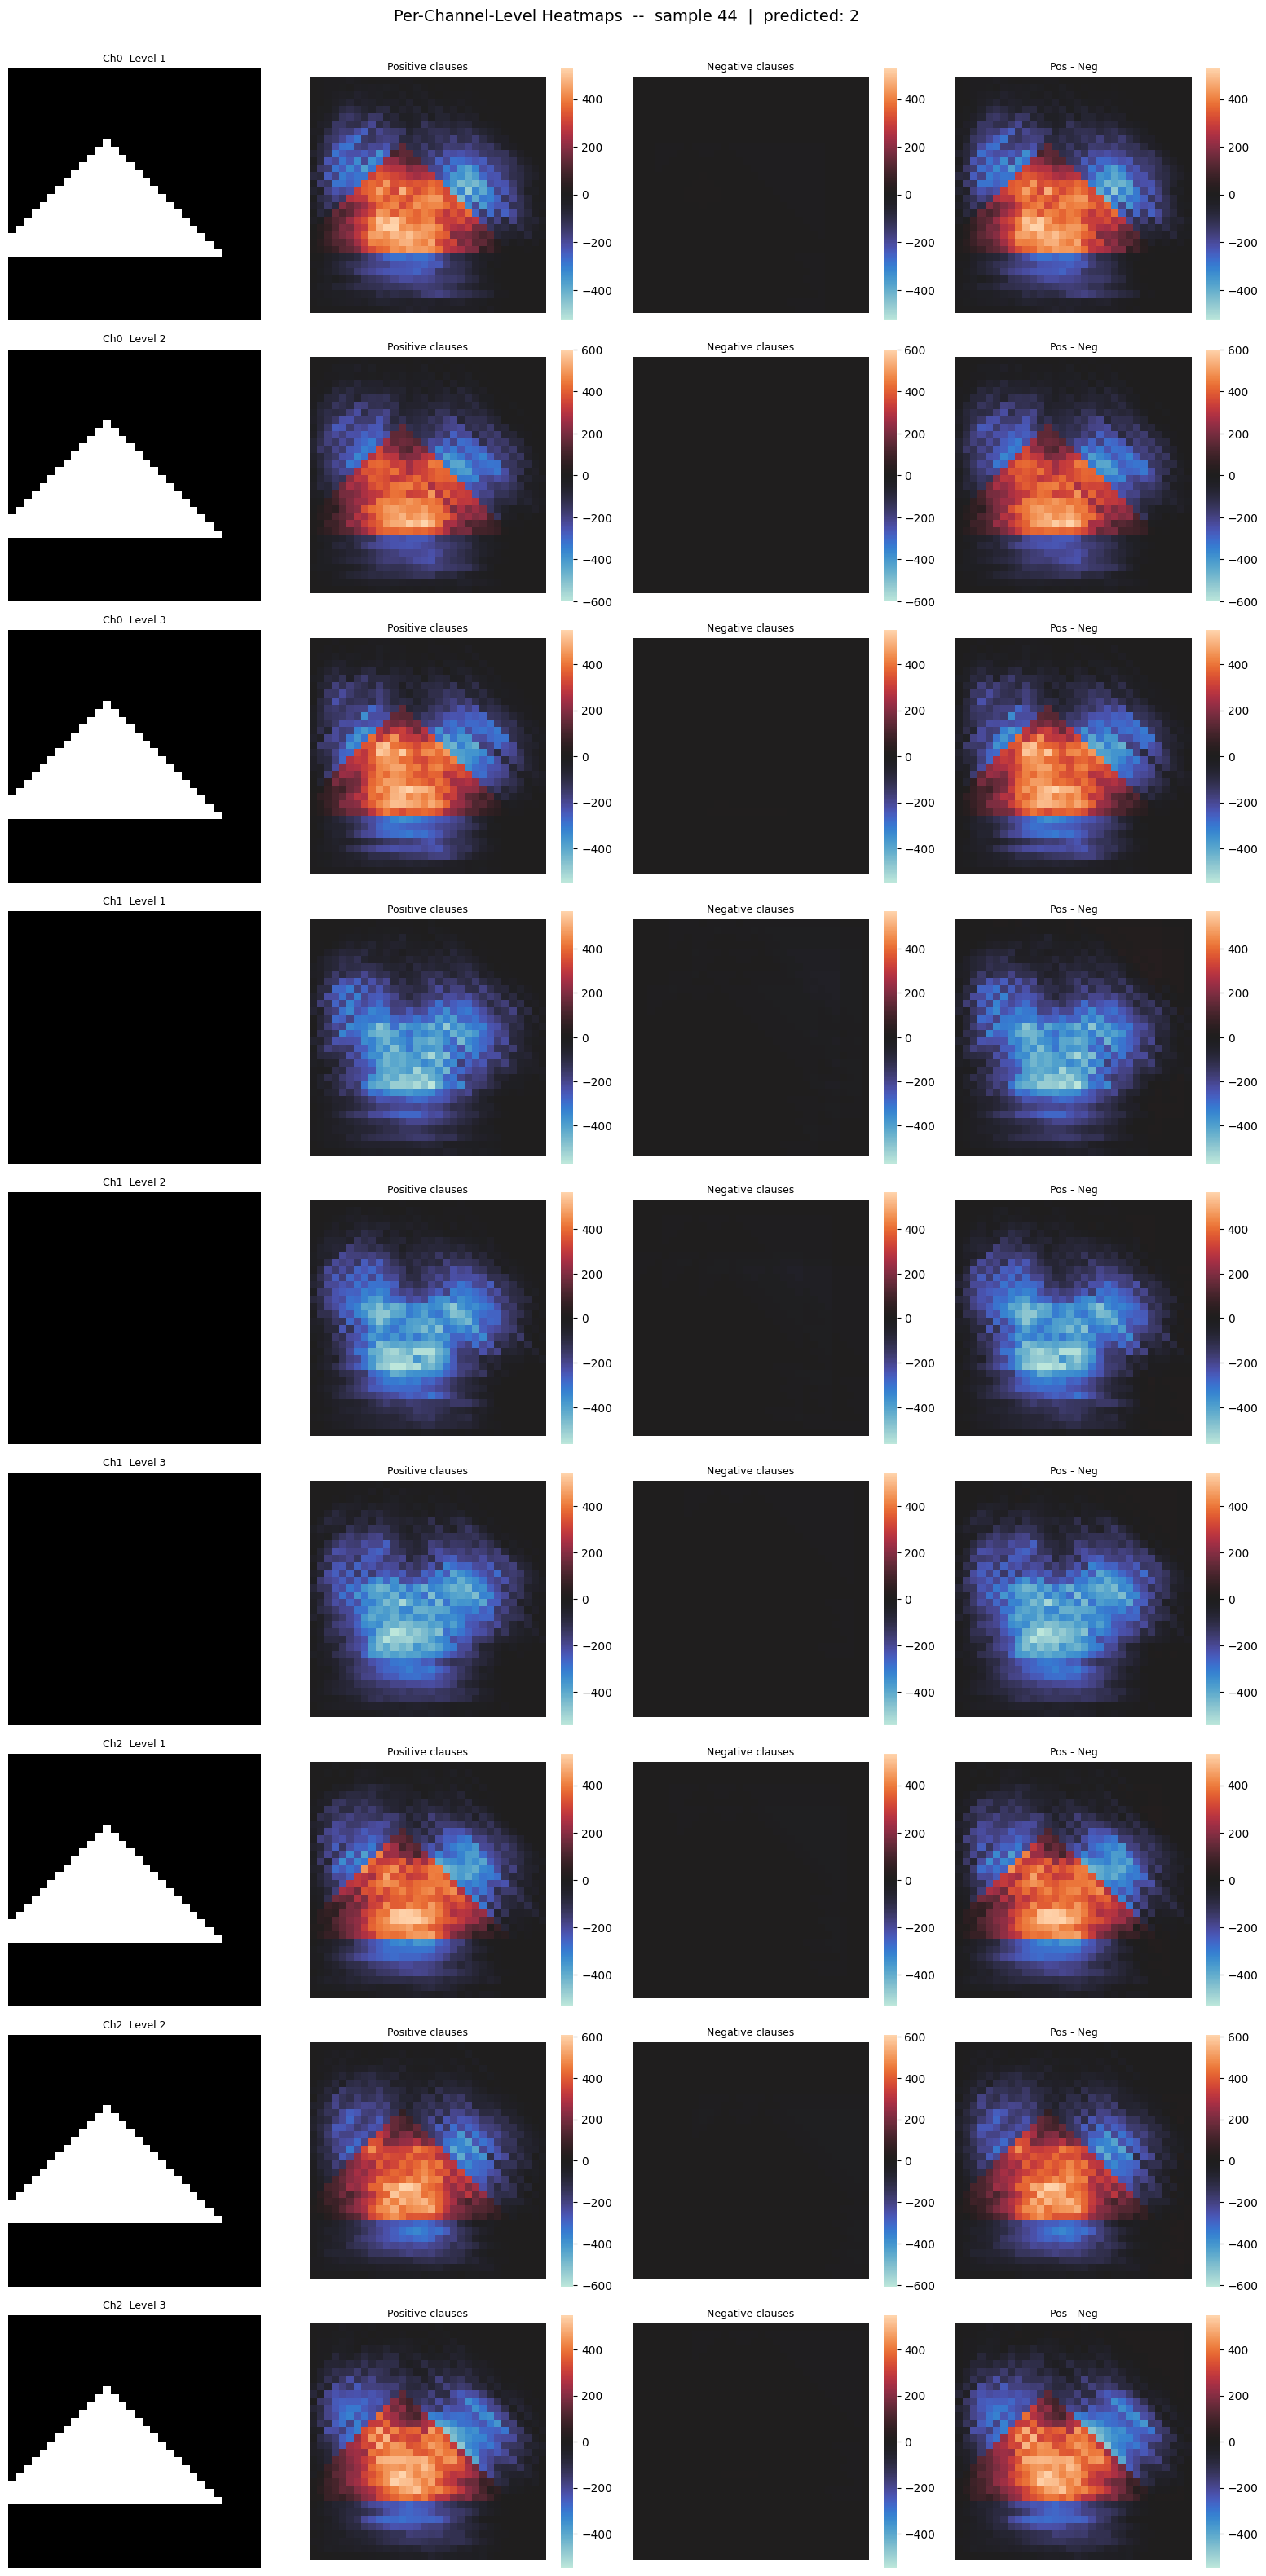

In [10]:
image_index = np.random.randint(0, len(X_test))
print(f"Showing sample index: {image_index}")

visualize_aggregated_heatmap(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=3,
    n_channels=3,
    image_shape=(32, 32))

visualize_per_channel_heatmaps(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=3,
    n_channels=3,
    image_shape=(32, 32))

visualize_per_channel_level_heatmaps(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=3,
    n_channels=3,
    image_shape=(32, 32))

In [11]:
_, _, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm,
    resolution=3, n_channels=3, image_shape=(32, 32),
    target_class=1, max_samples=200)

Averaging over 200 correctly predicted samples of class 1


KeyboardInterrupt: 